# Traffic Flow Analysis — Nagel-Schreckenberg Cellular Automaton
**Mathematical Modelling 2 — CW2**

This notebook implements a discrete stochastic model (cellular automaton) for single-lane one-way traffic flow, with and without equidistant traffic lights. The goal is to optimise through-flow as a function of:
- Inflow rate
- Maximum velocity
- Number of traffic lights
- Switching cycle duration and green/red split

**Model**: Nagel-Schreckenberg (NaSch) cellular automaton — Ref [18] in the CW2 bibliography.  
**Traffic lights**: Adaptation following Rickert et al. [17].

## 1. Imports & Global Parameters

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec

np.random.seed(42)

# ── Road parameters ──────────────────────────────────────────────────────────
L         = 500    # Road length (number of cells)
V_MAX     = 5      # Default maximum velocity (cells per timestep)
P_RAND    = 0.3    # Dawdling/randomisation probability

# ── Simulation parameters ────────────────────────────────────────────────────
T_WARMUP  = 500    # Timesteps discarded before measurement
T_MEASURE = 1000   # Timesteps used for averaging

print(f"Road length: {L} cells | v_max: {V_MAX} | p_rand: {P_RAND}")
print(f"Warmup: {T_WARMUP} steps | Measurement: {T_MEASURE} steps")

Road length: 500 cells | v_max: 5 | p_rand: 0.3
Warmup: 500 steps | Measurement: 1000 steps


## 2. Core NaSch Cellular Automaton

The **Nagel-Schreckenberg model** (1992) uses four update rules applied **simultaneously** to every car each timestep:

1. **Acceleration**: $v_i \leftarrow \min(v_i + 1,\; v_\text{max})$
2. **Braking**: $v_i \leftarrow \min(v_i,\; d_i - 1)$ where $d_i$ = gap to next car
3. **Randomisation**: with probability $p$, $v_i \leftarrow \max(v_i - 1,\; 0)$
4. **Movement**: $x_i \leftarrow x_i + v_i$

**Boundary conditions**: Open — cars enter cell 0 with probability $p_\text{in}$ and exit at cell $L$.

In [2]:
class TrafficCA:
    """
    Nagel-Schreckenberg cellular automaton with open boundary conditions.

    Road state: 1D array of length L.
      cell = -1  → empty
      cell >= 0  → car with velocity v
    A parallel `car_ids` array assigns each injected car a unique integer ID
    that travels with it until it exits the road. This lets us tag and follow
    an individual car through a space-time diagram.
    """

    def __init__(self, L=500, v_max=5, p_rand=0.3, p_in=0.5):
        self.L      = L
        self.v_max  = v_max
        self.p_rand = p_rand
        self.p_in   = p_in
        self.road    = np.full(L, -1, dtype=int)  # start empty
        self.car_ids = np.full(L, -1, dtype=int)  # parallel ID array
        self.next_id = 0
        self.time   = 0
        self.outflow_count = 0  # cars that exited during measurement

    def reset(self):
        self.road[:]    = -1
        self.car_ids[:] = -1
        self.next_id    = 0
        self.time       = 0
        self.outflow_count = 0

    # ── Internal helpers ──────────────────────────────────────────────────────

    def _car_positions(self):
        return np.where(self.road >= 0)[0]

    def _gap_ahead(self, pos):
        """
        Gap (number of empty cells) between car at `pos` and
        the next obstacle (car or road boundary).
        Returns L - pos if no obstacle is found (open road to boundary).
        """
        road = self.road
        gap = 0
        for j in range(pos + 1, self.L):
            if road[j] >= 0:
                return gap
            gap += 1
        return gap  # reached end of road

    def _gap_to_obstacles(self, positions, obstacle_positions):
        """
        Vectorised: for each car position, find distance to next obstacle
        (car or red light). Returns array of gaps.
        `obstacle_positions` is sorted array of all blocking cell indices.
        """
        gaps = np.full(len(positions), self.L, dtype=int)
        if len(obstacle_positions) == 0:
            # no obstacles — gap is distance to road end
            gaps = self.L - positions
            return gaps
        for i, p in enumerate(positions):
            # find first obstacle strictly ahead
            idx = np.searchsorted(obstacle_positions, p, side='right')
            if idx < len(obstacle_positions):
                gaps[i] = obstacle_positions[idx] - p - 1
            else:
                gaps[i] = self.L - p  # free run to exit
        return gaps

    # ── Red-light obstacle positions (overridden by subclass) ─────────────────

    def _red_light_positions(self):
        """Return array of cell indices where a red light blocks traffic."""
        return np.array([], dtype=int)

    # ── Main update step ──────────────────────────────────────────────────────

    def step(self, record_flow=False):
        road    = self.road
        L       = self.L
        v_max   = self.v_max
        p_rand  = self.p_rand

        car_pos = self._car_positions()
        if len(car_pos) == 0:
            self._inflow()
            self.time += 1
            return

        # Obstacle list = cars + red lights
        red_pos = self._red_light_positions()
        obstacles = np.sort(np.concatenate([car_pos, red_pos]))

        velocities = road[car_pos].copy()

        # Rule 1: Acceleration
        velocities = np.minimum(velocities + 1, v_max)

        # Rule 2: Braking — gap to nearest obstacle ahead
        gaps = self._gap_to_obstacles(car_pos, obstacles)
        velocities = np.minimum(velocities, gaps)
        velocities = np.maximum(velocities, 0)

        # Rule 3: Randomisation
        rand_mask = np.random.random(len(car_pos)) < p_rand
        velocities[rand_mask] = np.maximum(velocities[rand_mask] - 1, 0)

        # Rule 4: Movement — build new road + id state
        new_road = np.full(L, -1, dtype=int)
        new_ids  = np.full(L, -1, dtype=int)
        new_pos  = car_pos + velocities

        exited = new_pos >= L
        if record_flow:
            self.outflow_count += int(np.sum(exited))

        staying = ~exited
        new_road[new_pos[staying]] = velocities[staying]
        new_ids[new_pos[staying]]  = self.car_ids[car_pos][staying]

        self.road    = new_road
        self.car_ids = new_ids

        # Inflow at cell 0
        self._inflow()
        self.time += 1

    def _inflow(self):
        """Inject a new car at cell 0 with probability p_in if cell is free."""
        if self.road[0] < 0 and np.random.random() < self.p_in:
            self.road[0]    = 0              # new car, velocity 0
            self.car_ids[0] = self.next_id   # assign fresh ID
            self.next_id   += 1

    # ── Simulation runners ────────────────────────────────────────────────────

    def warmup(self, T=None):
        T = T or T_WARMUP
        for _ in range(T):
            self.step(record_flow=False)
        self.outflow_count = 0

    def run(self, T=None):
        """Run T measurement steps, return mean flow (cars/timestep)."""
        T = T or T_MEASURE
        self.outflow_count = 0
        for _ in range(T):
            self.step(record_flow=True)
        return self.outflow_count / T

    def get_snapshot(self):
        """Return binary occupancy array (1=car, 0=empty)."""
        return (self.road >= 0).astype(int)

    def density(self):
        return np.sum(self.road >= 0) / self.L


print("TrafficCA class defined.")

TrafficCA class defined.


## 3. Traffic Lights Extension

Traffic lights are added by overriding `_red_light_positions()`. When a light is **red**, its cell acts as a phantom obstacle — cars brake as if another car occupied that cell.

- `N` lights at positions $\left\lfloor L \cdot \frac{i+1}{N+1} \right\rfloor$ for $i = 0, \ldots, N-1$
- Each light cycles: **green** for `T_green` steps then **red** for `T_red = T_cycle - T_green` steps
- **Synchronised**: all lights start in the same phase
- **Offset**: light $i$ starts with phase shift $i \cdot T_\text{cycle} / N$ (green wave coordination)

In [3]:
class TrafficCAWithLights(TrafficCA):
    """
    NaSch CA extended with N equidistant traffic lights.

    Parameters
    ----------
    N          : number of traffic lights
    T_cycle    : total switching cycle length (timesteps)
    T_green    : number of green timesteps per cycle (T_red = T_cycle - T_green)
    offset     : if True, consecutive lights are phase-shifted by T_cycle/N
    """

    def __init__(self, L=500, v_max=5, p_rand=0.3, p_in=0.5,
                 N=2, T_cycle=30, T_green=None, offset=False):
        super().__init__(L=L, v_max=v_max, p_rand=p_rand, p_in=p_in)
        self.N       = N
        self.T_cycle = T_cycle
        self.T_green = T_green if T_green is not None else T_cycle // 2
        self.offset  = offset

        # Light positions — evenly spaced
        self.light_pos = np.array(
            [L * (i + 1) // (N + 1) for i in range(N)], dtype=int
        )

        # Phase offsets per light
        if offset:
            self.phase_offsets = np.array(
                [int(i * T_cycle / N) for i in range(N)], dtype=int
            )
        else:
            self.phase_offsets = np.zeros(N, dtype=int)

    def _light_is_red(self, light_idx):
        """Return True if light `light_idx` is currently red."""
        phase = (self.time + self.phase_offsets[light_idx]) % self.T_cycle
        return phase >= self.T_green  # green phase first, then red

    def _red_light_positions(self):
        """Return positions of all currently red lights."""
        red = [self.light_pos[i] for i in range(self.N) if self._light_is_red(i)]
        return np.array(red, dtype=int)

    def light_states(self):
        """Return dict of {position: 'green'/'red'} for current timestep."""
        return {
            self.light_pos[i]: ('red' if self._light_is_red(i) else 'green')
            for i in range(self.N)
        }


print("TrafficCAWithLights class defined.")

TrafficCAWithLights class defined.


## 4. Validation — Fundamental Diagram (Closed Boundary)

We first validate the model using **periodic (closed) boundary conditions** to reproduce the classic NaSch fundamental diagram: flow $J$ vs density $\rho$.

With periodic boundaries, density is fixed and $J = \rho \cdot \langle v \rangle$.

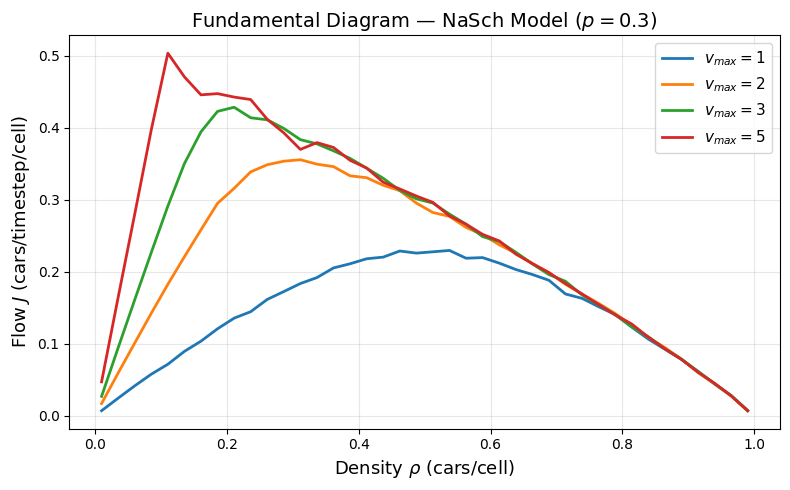

Fundamental diagrams computed. Each curve shows the classic hump shape:
free-flow on the left, capacity at the peak, and congestion on the right.


In [4]:
class TrafficCA_Periodic:
    """NaSch CA with periodic (closed) boundary — for fundamental diagram."""

    def __init__(self, L=500, n_cars=100, v_max=5, p_rand=0.3):
        self.L      = L
        self.v_max  = v_max
        self.p_rand = p_rand
        self.road   = np.full(L, -1, dtype=int)
        # Place cars randomly
        positions = np.random.choice(L, n_cars, replace=False)
        self.road[positions] = np.random.randint(0, v_max + 1, n_cars)

    def step(self):
        road   = self.road
        L      = self.L
        v_max  = self.v_max
        p_rand = self.p_rand

        car_pos = np.where(road >= 0)[0]
        if len(car_pos) == 0:
            return

        velocities = road[car_pos].copy()

        # Rule 1: Acceleration
        velocities = np.minimum(velocities + 1, v_max)

        # Rule 2: Braking — periodic gap
        gaps = np.empty(len(car_pos), dtype=int)
        for i, p in enumerate(car_pos):
            g = 0
            for j in range(1, L):
                if road[(p + j) % L] >= 0:
                    break
                g += 1
            gaps[i] = g
        velocities = np.minimum(velocities, gaps)
        velocities = np.maximum(velocities, 0)

        # Rule 3: Randomisation
        rand_mask = np.random.random(len(car_pos)) < p_rand
        velocities[rand_mask] = np.maximum(velocities[rand_mask] - 1, 0)

        # Rule 4: Movement (periodic wrap)
        new_road = np.full(L, -1, dtype=int)
        new_pos  = (car_pos + velocities) % L
        new_road[new_pos] = velocities
        self.road = new_road

    def mean_flow(self):
        car_pos = np.where(self.road >= 0)[0]
        if len(car_pos) == 0:
            return 0.0
        return float(np.mean(self.road[car_pos])) * len(car_pos) / self.L


def fundamental_diagram(v_max=5, L=200, p_rand=0.3, n_densities=40,
                         T_warmup=300, T_measure=500):
    """Compute J vs rho for the periodic NaSch model."""
    densities = np.linspace(0.01, 0.99, n_densities)
    flows     = np.zeros(n_densities)
    for k, rho in enumerate(densities):
        n_cars = max(1, int(rho * L))
        sim = TrafficCA_Periodic(L=L, n_cars=n_cars, v_max=v_max, p_rand=p_rand)
        for _ in range(T_warmup):
            sim.step()
        J = 0.0
        for _ in range(T_measure):
            sim.step()
            J += sim.mean_flow()
        flows[k] = J / T_measure
    return densities, flows


# ── Plot fundamental diagrams for several v_max values ────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

for vmax in [1, 2, 3, 5]:
    rho, J = fundamental_diagram(v_max=vmax, L=200, p_rand=0.3)
    ax.plot(rho, J, label=f'$v_{{max}}={vmax}$', linewidth=2)

ax.set_xlabel('Density $\\rho$ (cars/cell)', fontsize=13)
ax.set_ylabel('Flow $J$ (cars/timestep/cell)', fontsize=13)
ax.set_title('Fundamental Diagram — NaSch Model ($p=0.3$)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Fundamental diagrams computed. Each curve shows the classic hump shape:")
print("free-flow on the left, capacity at the peak, and congestion on the right.")

## 5. Open Boundary Analysis — Through-Flow vs Inflow Rate

With open boundaries, the inflow probability $p_\text{in}$ controls how many cars try to enter. We measure the steady-state **through-flow** (cars exiting per timestep) as $p_\text{in}$ varies from 0 to 1.

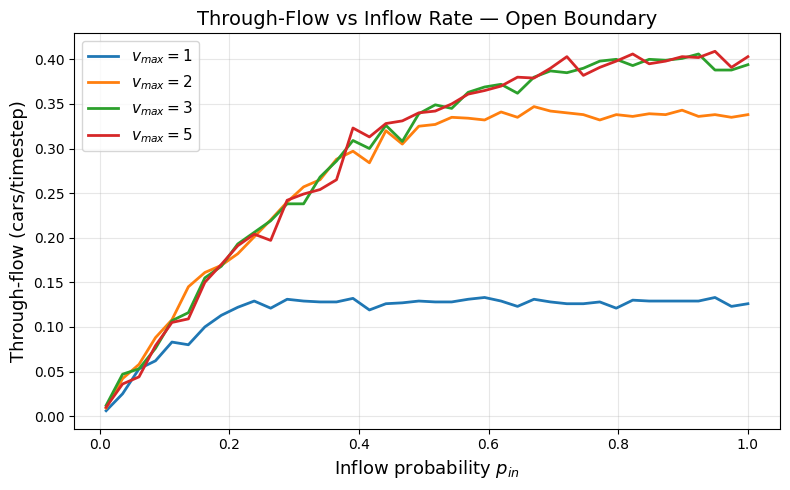

Through-flow saturates once the road reaches capacity.
Higher v_max → higher saturation flow (road capacity).


In [5]:
def sweep_inflow(v_max=5, L=L, p_rand=P_RAND,
                 p_in_values=None, T_warmup=T_WARMUP, T_measure=T_MEASURE):
    """Measure through-flow for a range of inflow probabilities."""
    if p_in_values is None:
        p_in_values = np.linspace(0.01, 1.0, 40)
    flows = np.zeros(len(p_in_values))
    for k, p_in in enumerate(p_in_values):
        sim = TrafficCA(L=L, v_max=v_max, p_rand=p_rand, p_in=p_in)
        sim.warmup(T_warmup)
        flows[k] = sim.run(T_measure)
    return p_in_values, flows


p_vals = np.linspace(0.01, 1.0, 40)

fig, ax = plt.subplots(figsize=(8, 5))
for vmax in [1, 2, 3, 5]:
    p_in, flow = sweep_inflow(v_max=vmax, p_in_values=p_vals)
    ax.plot(p_in, flow, label=f'$v_{{max}}={vmax}$', linewidth=2)

ax.set_xlabel('Inflow probability $p_{{in}}$', fontsize=13)
ax.set_ylabel('Through-flow (cars/timestep)', fontsize=13)
ax.set_title('Through-Flow vs Inflow Rate — Open Boundary', fontsize=14)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("Through-flow saturates once the road reaches capacity.")
print("Higher v_max → higher saturation flow (road capacity).")

## 6. Space-Time Diagrams

Space-time diagrams show car positions (x-axis) at each timestep (y-axis). They reveal:
- **Free flow**: diagonal tracks (cars moving steadily)
- **Stop-and-go waves**: backward-propagating density waves (characteristic of congestion)
- **Traffic light effects**: queues forming and clearing at light positions

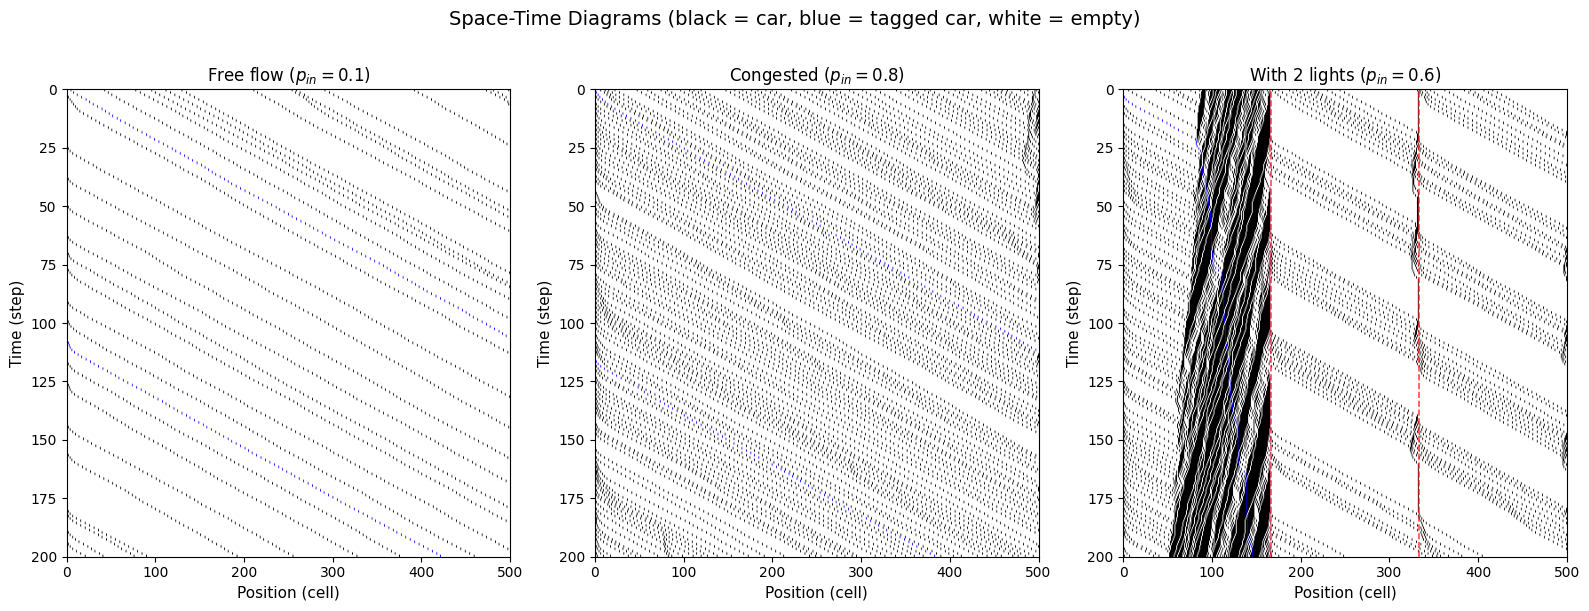

Left: sparse diagonal tracks = free flow.
Middle: backward-tilted bands = stop-and-go waves.
Right: queues form and clear at red dashed light positions.
Blue trail: the journey of one tagged car — follow it through each scenario.


In [6]:
from matplotlib.colors import ListedColormap, BoundaryNorm

# 3-value grid encoding used by every space-time plot below:
#   0 = empty, 1 = regular car, 2 = tagged car (rendered blue)
ST_CMAP = ListedColormap(['white', 'black', 'blue'])
ST_NORM = BoundaryNorm([-0.5, 0.5, 1.5, 2.5], ST_CMAP.N)


def record_spacetime(sim, T_warmup=300, T_record=200):
    """Run sim and record occupancy grid of shape (T_record, L).

    One car is tagged so we can follow it through the diagram. The tagged
    car's cell is marked with value 2 (plotted blue); all other cars are
    value 1 (black). If the tagged car exits the road, the rearmost car
    still on the road inherits the tag so the blue trail continues.
    """
    for _ in range(T_warmup):
        sim.step()

    # Pick the rearmost car currently on the road; if the road is empty,
    # wait until a fresh car is injected and tag that one.
    def _rearmost_id():
        occ = np.where(sim.road >= 0)[0]
        return int(sim.car_ids[occ[0]]) if len(occ) else None

    tag_id = _rearmost_id()

    grid = np.zeros((T_record, sim.L), dtype=int)
    for t in range(T_record):
        snap = sim.get_snapshot()

        if tag_id is None:
            tag_id = _rearmost_id()
        else:
            if not np.any(sim.car_ids == tag_id):
                # tagged car has exited — inherit tag from rearmost remaining car
                tag_id = _rearmost_id()

        if tag_id is not None:
            tag_cells = np.where(sim.car_ids == tag_id)[0]
            if len(tag_cells):
                snap[tag_cells[0]] = 2  # mark as tagged

        grid[t] = snap
        sim.step()
    return grid


fig, axes = plt.subplots(1, 3, figsize=(16, 6))
scenarios = [
    ("Free flow ($p_{in}=0.1$)",      TrafficCA(L=L, v_max=5, p_rand=P_RAND, p_in=0.1)),
    ("Congested ($p_{in}=0.8$)",       TrafficCA(L=L, v_max=5, p_rand=P_RAND, p_in=0.8)),
    ("With 2 lights ($p_{in}=0.6$)",   TrafficCAWithLights(L=L, v_max=5, p_rand=P_RAND,
                                                           p_in=0.6, N=2, T_cycle=40, T_green=20)),
]

for ax, (title, sim) in zip(axes, scenarios):
    grid = record_spacetime(sim, T_warmup=300, T_record=200)
    ax.imshow(grid, aspect='auto', cmap=ST_CMAP, norm=ST_NORM,
              origin='upper', extent=[0, L, 200, 0])

    # Mark light positions if applicable
    if hasattr(sim, 'light_pos'):
        for lp in sim.light_pos:
            ax.axvline(lp, color='red', linewidth=1.2, alpha=0.7, linestyle='--')

    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Position (cell)', fontsize=11)
    ax.set_ylabel('Time (step)', fontsize=11)

plt.suptitle('Space-Time Diagrams (black = car, blue = tagged car, white = empty)',
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

print("Left: sparse diagonal tracks = free flow.")
print("Middle: backward-tilted bands = stop-and-go waves.")
print("Right: queues form and clear at red dashed light positions.")
print("Blue trail: the journey of one tagged car — follow it through each scenario.")

## 6b. How Traffic Lights Work — Red/Green Alternation

The previous figure marks light positions with a static red dashed line — but a real traffic light *alternates* between red and green over time. Below, the same two-light scenario is re-rendered with the light columns drawn as **alternating red/green bands** along the time axis:

- **Left panel** — the pure light-cycle timeline (no cars). Each column shows one light's state over the 200 recorded timesteps: green when cars can pass, red when they must stop.
- **Right panel** — the full space-time diagram, with the red/green bands overlaid at x=167 and x=333. Black pixels are cars. During a **red** band, a queue (dense backward-tilted wedge) builds upstream of the light; the moment the band flips to **green**, the queue discharges and cars stream through.

Cycle: `T_cycle = 40`, `T_green = 20` (so 20 steps green, 20 steps red, repeating).

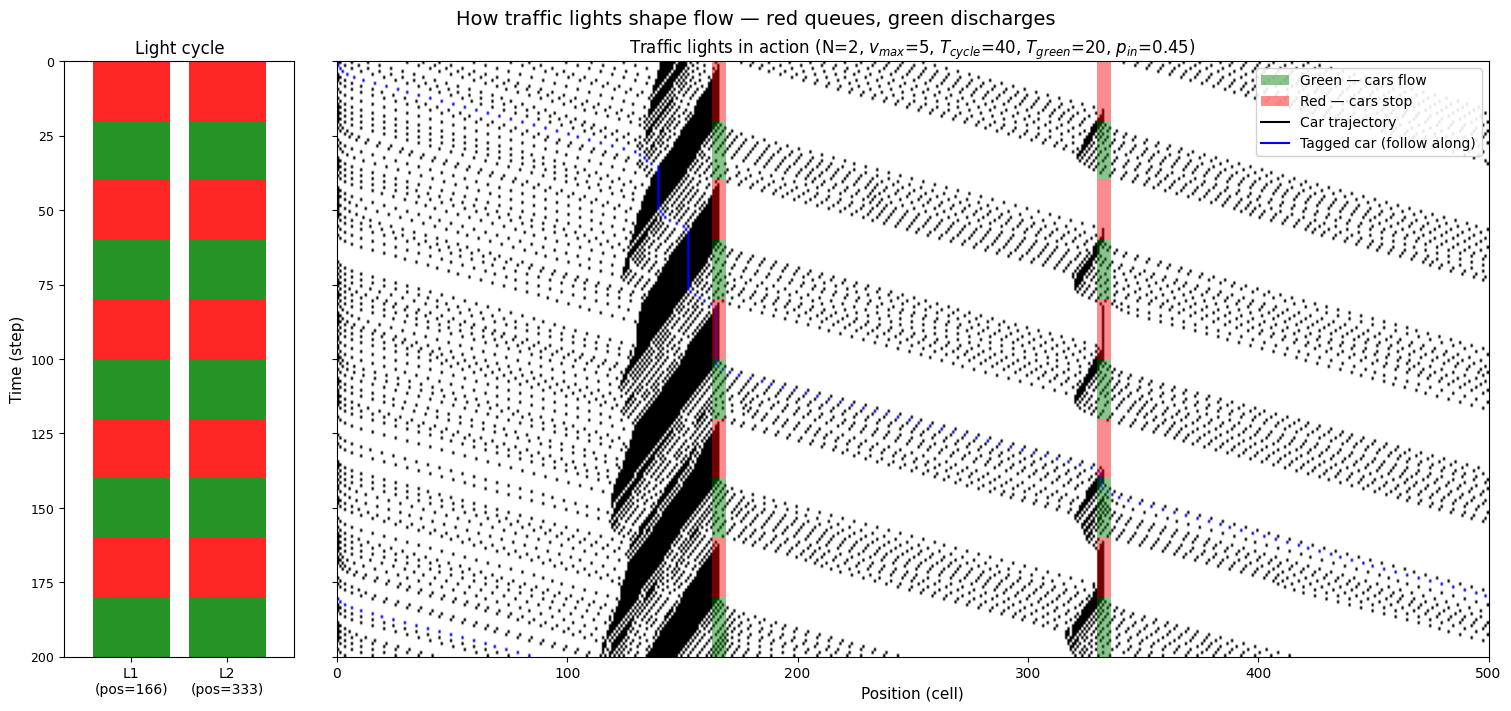

Left panel: each column is one light's red/green timeline over 200 steps.
Right panel: watch diagonal car tracks stream through every green window,
             then halt against the next red band before continuing.
Blue trail: one tagged car — follow it as it queues at reds and streams on greens.


In [7]:
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def light_band_intervals(phase_offset, T_cycle, T_green, T_warmup, T_record):
    """Collapse per-timestep light state into (t_start, t_end, color) intervals."""
    intervals = []
    cur_color, cur_start = None, 0
    for tr in range(T_record):
        phase = (T_warmup + tr + phase_offset) % T_cycle
        color = 'green' if phase < T_green else 'red'
        if color != cur_color:
            if cur_color is not None:
                intervals.append((cur_start, tr, cur_color))
            cur_color, cur_start = color, tr
    intervals.append((cur_start, T_record, cur_color))
    return intervals


# ── Build the simulation ─────────────────────────────────────────────────────
# Params tuned so the "cars flow on green, stop on red" effect is visually obvious:
#   v_max = 5    → standard NaSch max velocity (matches V_MAX global)
#   p_rand = 0.1 → minimal dawdling, so tracks stay crisp
#   p_in = 0.45  → enough cars for a queue at red, but Light 1 doesn't jam solid
p_in_demo  = 0.45
v_max_demo = 5
p_rand_demo = 0.1

np.random.seed(42)
T_warmup, T_record = 300, 200
sim = TrafficCAWithLights(L=L, v_max=v_max_demo, p_rand=p_rand_demo, p_in=p_in_demo,
                          N=2, T_cycle=40, T_green=20)
grid = record_spacetime(sim, T_warmup=T_warmup, T_record=T_record)

band_width = 6   # cells — total width of the red/green overlay at each light
BAND_ALPHA = 0.45

# ── Figure: 2 panels sharing the time axis ───────────────────────────────────
fig = plt.figure(figsize=(15, 7), constrained_layout=True)
gs  = GridSpec(1, 2, width_ratios=[1, 5], wspace=0.05, figure=fig)
ax_cycle = fig.add_subplot(gs[0, 0])
ax_st    = fig.add_subplot(gs[0, 1], sharey=ax_cycle)

# ── Panel A: pure light-cycle timeline ───────────────────────────────────────
slot_halfwidth = 0.4
for i, lp in enumerate(sim.light_pos):
    intervals = light_band_intervals(
        phase_offset=int(sim.phase_offsets[i]),
        T_cycle=sim.T_cycle, T_green=sim.T_green,
        T_warmup=T_warmup, T_record=T_record,
    )
    for t0, t1, color in intervals:
        ax_cycle.fill_betweenx(
            [t0, t1], i - slot_halfwidth, i + slot_halfwidth,
            color=color, alpha=0.85, edgecolor='none',
        )

ax_cycle.set_xlim(-0.7, len(sim.light_pos) - 0.3)
ax_cycle.set_ylim(T_record, 0)
ax_cycle.set_xticks(range(len(sim.light_pos)))
ax_cycle.set_xticklabels(
    [f"L{i+1}\n(pos={lp})" for i, lp in enumerate(sim.light_pos)],
    fontsize=10,
)
ax_cycle.set_ylabel("Time (step)", fontsize=11)
ax_cycle.set_title("Light cycle", fontsize=12)
ax_cycle.tick_params(axis='y', labelsize=9)

# ── Panel B: space-time + red/green bands ────────────────────────────────────
ax_st.imshow(grid, aspect='auto', cmap=ST_CMAP, norm=ST_NORM, origin='upper',
             extent=[0, L, T_record, 0])

for i, lp in enumerate(sim.light_pos):
    intervals = light_band_intervals(
        phase_offset=int(sim.phase_offsets[i]),
        T_cycle=sim.T_cycle, T_green=sim.T_green,
        T_warmup=T_warmup, T_record=T_record,
    )
    for t0, t1, color in intervals:
        ax_st.fill_betweenx(
            [t0, t1], lp - band_width / 2, lp + band_width / 2,
            color=color, alpha=BAND_ALPHA, edgecolor='none',
        )

ax_st.set_xlim(0, L)
ax_st.set_xlabel("Position (cell)", fontsize=11)
ax_st.set_title(
    f"Traffic lights in action (N={sim.N}, $v_{{max}}$={v_max_demo}, "
    f"$T_{{cycle}}$={sim.T_cycle}, $T_{{green}}$={sim.T_green}, "
    f"$p_{{in}}$={p_in_demo})",
    fontsize=12,
)
plt.setp(ax_st.get_yticklabels(), visible=False)

legend_handles = [
    Patch(facecolor='green', alpha=BAND_ALPHA, label='Green — cars flow'),
    Patch(facecolor='red',   alpha=BAND_ALPHA, label='Red — cars stop'),
    Line2D([0], [0], color='black', lw=1.5, label='Car trajectory'),
    Line2D([0], [0], color='blue',  lw=1.5, label='Tagged car (follow along)'),
]
ax_st.legend(handles=legend_handles, loc='upper right', fontsize=10,
             framealpha=0.9)

fig.suptitle(
    "How traffic lights shape flow — red queues, green discharges",
    fontsize=14,
)
plt.show()

print("Left panel: each column is one light's red/green timeline over 200 steps.")
print("Right panel: watch diagonal car tracks stream through every green window,")
print("             then halt against the next red band before continuing.")
print("Blue trail: one tagged car — follow it as it queues at reds and streams on greens.")

## 6b2. Anti-Phased Traffic Lights — One Green, One Red

Section 6b ran the two lights **in phase** — both green together, both red together. Here we use the *opposite* configuration: Light 2 is phase-shifted by `T_cycle / 2`, so whenever Light 1 is green, Light 2 is red (and vice versa). This is the exact anti-phase regime.

- Same two-light scenario, same `T_cycle = 40`, `T_green = 20`.
- Achieved with the existing `offset=True` flag on `TrafficCAWithLights`: for N=2 with `T_green = T_cycle / 2`, the phase offsets become `[0, 20]`, which is perfect anti-phase.

Expect:
- **Left panel** — the L1 and L2 cycle columns are mirror images of each other (opposite colour at every time slice).
- **Right panel** — queues build at only *one* of the two light positions at a time; the other is simultaneously discharging. The two lights never clear together.

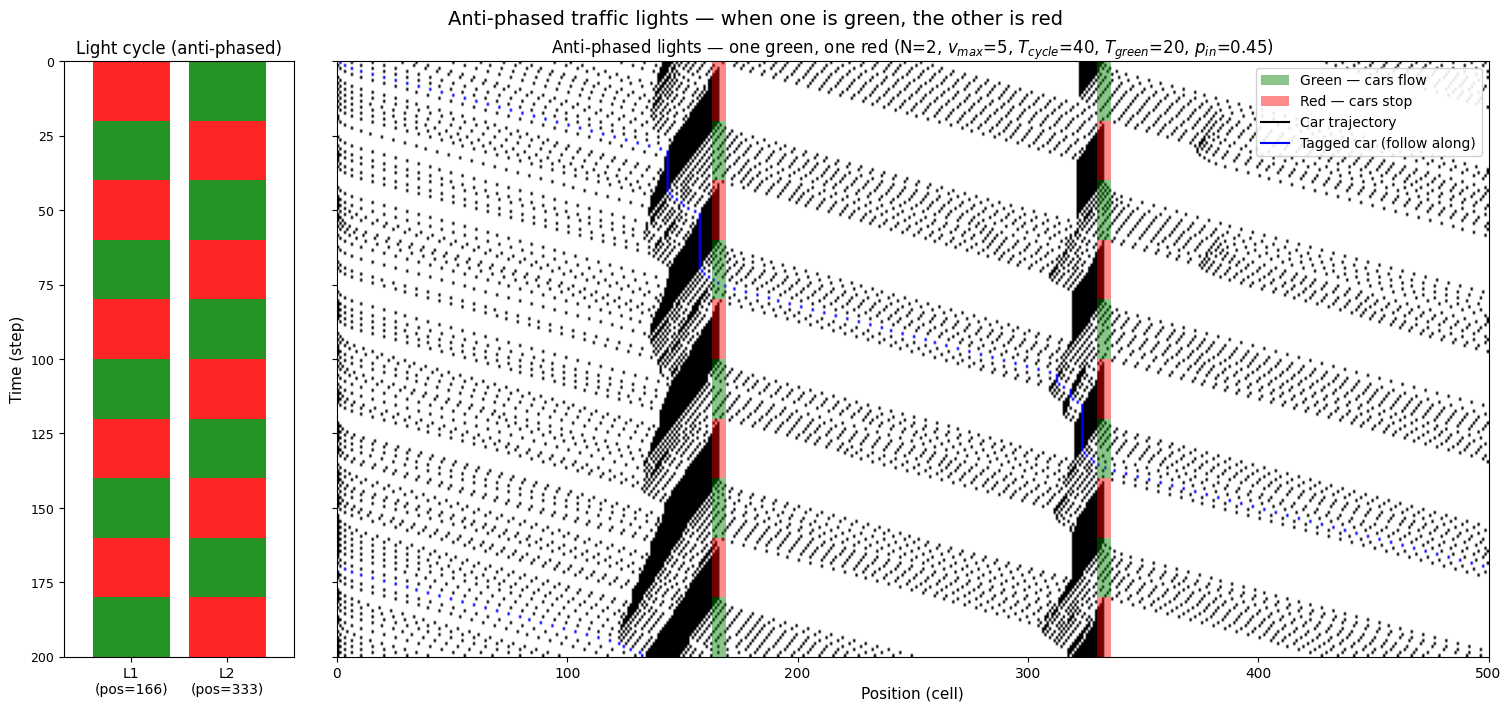

Left panel: L1 and L2 columns are mirror images — opposite colour at every time slice.
Right panel: queues form at only one light at a time; the other is simultaneously
             discharging. The two lights never clear together.
Blue trail: one tagged car — follow it as it alternates between being stopped and moving.


In [8]:
# ── Anti-phased two-light demo ───────────────────────────────────────────────
# Identical setup to 6b, but with offset=True so Light 2 is shifted by
# T_cycle/2 relative to Light 1 — i.e. one is always green while the other
# is red. Re-uses `record_spacetime` (cell 12) and `light_band_intervals`
# (cell 14) without redefining them.

p_in_demo   = 0.45
v_max_demo  = 5
p_rand_demo = 0.1

np.random.seed(42)
T_warmup, T_record = 300, 200
sim = TrafficCAWithLights(L=L, v_max=v_max_demo, p_rand=p_rand_demo, p_in=p_in_demo,
                          N=2, T_cycle=40, T_green=20, offset=True)
assert list(sim.phase_offsets) == [0, 20], "expected anti-phase offsets [0, 20]"
grid = record_spacetime(sim, T_warmup=T_warmup, T_record=T_record)

band_width = 6
BAND_ALPHA = 0.45

fig = plt.figure(figsize=(15, 7), constrained_layout=True)
gs  = GridSpec(1, 2, width_ratios=[1, 5], wspace=0.05, figure=fig)
ax_cycle = fig.add_subplot(gs[0, 0])
ax_st    = fig.add_subplot(gs[0, 1], sharey=ax_cycle)

# Panel A: light-cycle timeline
slot_halfwidth = 0.4
for i, lp in enumerate(sim.light_pos):
    intervals = light_band_intervals(
        phase_offset=int(sim.phase_offsets[i]),
        T_cycle=sim.T_cycle, T_green=sim.T_green,
        T_warmup=T_warmup, T_record=T_record,
    )
    for t0, t1, color in intervals:
        ax_cycle.fill_betweenx(
            [t0, t1], i - slot_halfwidth, i + slot_halfwidth,
            color=color, alpha=0.85, edgecolor='none',
        )

ax_cycle.set_xlim(-0.7, len(sim.light_pos) - 0.3)
ax_cycle.set_ylim(T_record, 0)
ax_cycle.set_xticks(range(len(sim.light_pos)))
ax_cycle.set_xticklabels(
    [f"L{i+1}\n(pos={lp})" for i, lp in enumerate(sim.light_pos)],
    fontsize=10,
)
ax_cycle.set_ylabel("Time (step)", fontsize=11)
ax_cycle.set_title("Light cycle (anti-phased)", fontsize=12)
ax_cycle.tick_params(axis='y', labelsize=9)

# Panel B: space-time + red/green bands
ax_st.imshow(grid, aspect='auto', cmap=ST_CMAP, norm=ST_NORM, origin='upper',
             extent=[0, L, T_record, 0])

for i, lp in enumerate(sim.light_pos):
    intervals = light_band_intervals(
        phase_offset=int(sim.phase_offsets[i]),
        T_cycle=sim.T_cycle, T_green=sim.T_green,
        T_warmup=T_warmup, T_record=T_record,
    )
    for t0, t1, color in intervals:
        ax_st.fill_betweenx(
            [t0, t1], lp - band_width / 2, lp + band_width / 2,
            color=color, alpha=BAND_ALPHA, edgecolor='none',
        )

ax_st.set_xlim(0, L)
ax_st.set_xlabel("Position (cell)", fontsize=11)
ax_st.set_title(
    f"Anti-phased lights — one green, one red "
    f"(N={sim.N}, $v_{{max}}$={v_max_demo}, "
    f"$T_{{cycle}}$={sim.T_cycle}, $T_{{green}}$={sim.T_green}, "
    f"$p_{{in}}$={p_in_demo})",
    fontsize=12,
)
plt.setp(ax_st.get_yticklabels(), visible=False)

legend_handles = [
    Patch(facecolor='green', alpha=BAND_ALPHA, label='Green — cars flow'),
    Patch(facecolor='red',   alpha=BAND_ALPHA, label='Red — cars stop'),
    Line2D([0], [0], color='black', lw=1.5, label='Car trajectory'),
    Line2D([0], [0], color='blue',  lw=1.5, label='Tagged car (follow along)'),
]
ax_st.legend(handles=legend_handles, loc='upper right', fontsize=10,
             framealpha=0.9)

fig.suptitle(
    "Anti-phased traffic lights — when one is green, the other is red",
    fontsize=14,
)
plt.show()

print("Left panel: L1 and L2 columns are mirror images — opposite colour at every time slice.")
print("Right panel: queues form at only one light at a time; the other is simultaneously")
print("             discharging. The two lights never clear together.")
print("Blue trail: one tagged car — follow it as it alternates between being stopped and moving.")

## 6c. Three Traffic Lights — Synchronised vs Green Wave

Sections 6b and 6b2 showed two-light coordination: in-phase (both red together) and anti-phase (one always red, one always green). With **three** lights we can see a true *green-wave* effect — each successive light turns green a fraction of `T_cycle` after the previous one, so a packet of cars released by L1 finds L2 just turning green by the time it arrives, then L3 by the time it reaches that point.

For $N=3$ with `T_cycle=40` and `T_green=20`, `offset=True` produces phase offsets $[0, 13, 26]$ ($\approx T_\text{cycle}/N$). The left panel uses synchronised lights (all in-phase); the right panel uses the green-wave configuration. Same $p_\text{in}$, same dawdling &mdash; only the coordination changes.

In [ ]:
# Three-light comparison: synchronised vs green-wave (offset).
# Re-uses record_spacetime, light_band_intervals, ST_CMAP, ST_NORM,
# Patch, Line2D, GridSpec — all defined earlier in Sections 6 / 6b.

p_in_demo   = 0.45
v_max_demo  = 5
p_rand_demo = 0.1

T_warmup, T_record = 300, 200
band_width = 6
BAND_ALPHA = 0.45

configs_3 = [
    ('synchronised',         False),
    ('green-wave (offset)',  True),
]

fig = plt.figure(figsize=(16, 7), constrained_layout=True)
gs   = GridSpec(1, 2, wspace=0.08, figure=fig)
axes = [fig.add_subplot(gs[0, k]) for k in range(2)]

for ax, (label, offset_flag) in zip(axes, configs_3):
    np.random.seed(42)
    sim = TrafficCAWithLights(L=L, v_max=v_max_demo, p_rand=p_rand_demo, p_in=p_in_demo,
                              N=3, T_cycle=40, T_green=20, offset=offset_flag)
    grid = record_spacetime(sim, T_warmup=T_warmup, T_record=T_record)

    ax.imshow(grid, aspect='auto', cmap=ST_CMAP, norm=ST_NORM, origin='upper',
              extent=[0, L, T_record, 0])

    for i, lp in enumerate(sim.light_pos):
        intervals = light_band_intervals(
            phase_offset=int(sim.phase_offsets[i]),
            T_cycle=sim.T_cycle, T_green=sim.T_green,
            T_warmup=T_warmup, T_record=T_record,
        )
        for t0, t1, color in intervals:
            ax.fill_betweenx(
                [t0, t1], lp - band_width / 2, lp + band_width / 2,
                color=color, alpha=BAND_ALPHA, edgecolor='none',
            )

    ax.set_xlim(0, L)
    ax.set_ylim(T_record, 0)
    ax.set_xlabel('Position (cell)', fontsize=11)
    ax.set_title(
        f"$N=3$, {label}\n"
        f"phase offsets = {list(sim.phase_offsets)}",
        fontsize=12,
    )

axes[0].set_ylabel('Time (step)', fontsize=11)
plt.setp(axes[1].get_yticklabels(), visible=False)

legend_handles = [
    Patch(facecolor='green', alpha=BAND_ALPHA, label='Green'),
    Patch(facecolor='red',   alpha=BAND_ALPHA, label='Red'),
    Line2D([0], [0], color='black', lw=1.5, label='Car trajectory'),
    Line2D([0], [0], color='blue',  lw=1.5, label='Tagged car'),
]
axes[1].legend(handles=legend_handles, loc='upper right', fontsize=10, framealpha=0.9)

fig.suptitle(
    f"Three traffic lights — synchronised vs green-wave coordination "
    f"($p_{{in}}={p_in_demo}$, $T_{{cycle}}=40$, $T_{{green}}=20$)",
    fontsize=14,
)
plt.show()

print("Synchronised: queues build simultaneously at all three lights, then clear together.")
print("Green-wave:   the green windows roll downstream — a packet of cars can chase the wave")
print("              through L1 -> L2 -> L3 with little waiting, but only at the right speed.")

## 6d. Four Traffic Lights — Synchronised vs Green Wave

Same comparison with **four** equidistant lights. For $N=4$, `T_cycle=40`, `offset=True` gives phase offsets $[0, 10, 20, 30]$ &mdash; each light lags the previous by $T_\text{cycle}/N = 10$ steps. The green-wave window is therefore narrower (10 steps instead of $\approx 13$ for $N=3$), so the chase-the-wave effect is more sensitive to dawdling and to the inflow rate.

In [ ]:
# Four-light comparison: synchronised vs green-wave (offset).
# Identical machinery to 6c, just N=4.

p_in_demo   = 0.45
v_max_demo  = 5
p_rand_demo = 0.1

T_warmup, T_record = 300, 200
band_width = 6
BAND_ALPHA = 0.45

configs_4 = [
    ('synchronised',         False),
    ('green-wave (offset)',  True),
]

fig = plt.figure(figsize=(16, 7), constrained_layout=True)
gs   = GridSpec(1, 2, wspace=0.08, figure=fig)
axes = [fig.add_subplot(gs[0, k]) for k in range(2)]

for ax, (label, offset_flag) in zip(axes, configs_4):
    np.random.seed(42)
    sim = TrafficCAWithLights(L=L, v_max=v_max_demo, p_rand=p_rand_demo, p_in=p_in_demo,
                              N=4, T_cycle=40, T_green=20, offset=offset_flag)
    grid = record_spacetime(sim, T_warmup=T_warmup, T_record=T_record)

    ax.imshow(grid, aspect='auto', cmap=ST_CMAP, norm=ST_NORM, origin='upper',
              extent=[0, L, T_record, 0])

    for i, lp in enumerate(sim.light_pos):
        intervals = light_band_intervals(
            phase_offset=int(sim.phase_offsets[i]),
            T_cycle=sim.T_cycle, T_green=sim.T_green,
            T_warmup=T_warmup, T_record=T_record,
        )
        for t0, t1, color in intervals:
            ax.fill_betweenx(
                [t0, t1], lp - band_width / 2, lp + band_width / 2,
                color=color, alpha=BAND_ALPHA, edgecolor='none',
            )

    ax.set_xlim(0, L)
    ax.set_ylim(T_record, 0)
    ax.set_xlabel('Position (cell)', fontsize=11)
    ax.set_title(
        f"$N=4$, {label}\n"
        f"phase offsets = {list(sim.phase_offsets)}",
        fontsize=12,
    )

axes[0].set_ylabel('Time (step)', fontsize=11)
plt.setp(axes[1].get_yticklabels(), visible=False)

legend_handles = [
    Patch(facecolor='green', alpha=BAND_ALPHA, label='Green'),
    Patch(facecolor='red',   alpha=BAND_ALPHA, label='Red'),
    Line2D([0], [0], color='black', lw=1.5, label='Car trajectory'),
    Line2D([0], [0], color='blue',  lw=1.5, label='Tagged car'),
]
axes[1].legend(handles=legend_handles, loc='upper right', fontsize=10, framealpha=0.9)

fig.suptitle(
    f"Four traffic lights — synchronised vs green-wave coordination "
    f"($p_{{in}}={p_in_demo}$, $T_{{cycle}}=40$, $T_{{green}}=20$)",
    fontsize=14,
)
plt.show()

print("Synchronised: four queues form and clear in lock-step — a hard global stop/go rhythm.")
print("Green-wave:   the green windows tile downstream every 10 steps; the tagged car can")
print("              ride the wave through all four lights if its dawdling doesn't fall behind.")